# 06b - Improved Baseline Models

**Improvements over 06_baseline_model**:
1. Reduce to 6 classes (merge DTE90 into DTE60)
2. Drop price-level and redundant correlated features
3. **Time-based train/test split** (no future leakage)
4. **Class weights** for imbalance
5. Hyperparameter tuning with Optuna
6. Two-stage model (moneyness + maturity separately)
7. LightGBM as additional model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)


All imports OK


## 1. Load and Prepare Data

In [2]:
# Load modeling data
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
data['decision_date'] = pd.to_datetime(data['decision_date'])
data = data.sort_values('decision_date').reset_index(drop=True)

print(f"Data shape: {data.shape}")
print(f"Date range: {data['decision_date'].min().date()} to {data['decision_date'].max().date()}")

Data shape: (1391, 37)
Date range: 2008-02-29 to 2025-12-31


## 2. Reduce to 6 Classes

Merge DTE90 into DTE60 -- the 3 DTE90 buckets have limited samples and are rarely optimal.

In [3]:
bucket_remap = {
    'ATM_DTE30': 'ATM_SHORT', 'ATM_DTE60': 'ATM_LONG', 'ATM_DTE90': 'ATM_LONG',
    'OTM5_DTE30': 'OTM5_SHORT', 'OTM5_DTE60': 'OTM5_LONG', 'OTM5_DTE90': 'OTM5_LONG',
    'OTM10_DTE30': 'OTM10_SHORT', 'OTM10_DTE60': 'OTM10_LONG', 'OTM10_DTE90': 'OTM10_LONG',
}

label_map_6 = {
    'ATM_SHORT': 0, 'ATM_LONG': 1,
    'OTM5_SHORT': 2, 'OTM5_LONG': 3,
    'OTM10_SHORT': 4, 'OTM10_LONG': 5
}
label_to_bucket_6 = {v: k for k, v in label_map_6.items()}

data['bucket_6'] = data['best_bucket'].map(bucket_remap)
data['label_6'] = data['bucket_6'].map(label_map_6)

print("6-Class distribution:")
for label in range(6):
    count = (data['label_6'] == label).sum()
    pct = count / len(data) * 100
    print(f"  {label} ({label_to_bucket_6[label]}): {count} ({pct:.1f}%)")

imbalance = data['label_6'].value_counts()
print(f"\nImbalance ratio: {imbalance.max()/imbalance.min():.1f}x")

6-Class distribution:
  0 (ATM_SHORT): 256 (18.4%)
  1 (ATM_LONG): 429 (30.8%)
  2 (OTM5_SHORT): 90 (6.5%)
  3 (OTM5_LONG): 272 (19.6%)
  4 (OTM10_SHORT): 97 (7.0%)
  5 (OTM10_LONG): 247 (17.8%)

Imbalance ratio: 4.8x


## 3. Feature Pruning

Drop price-level features and one from each highly correlated pair.

In [4]:
drop_features = ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']

exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket',
                'best_return', 'fiscalDateEnding', 'year', 'bucket_6', 'label_6']

feature_cols = [c for c in data.columns if c not in exclude_cols and c not in drop_features]

print(f"Features: {len(feature_cols)} (dropped {len(drop_features)})")
print(f"Dropped: {drop_features}")
print(f"Kept: {feature_cols}")

Features: 25 (dropped 5)
Dropped: ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']
Kept: ['vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma200', 'sma21_above_sma50', 'sma50_above_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'high_vol_regime', 'gross_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']


## 4. Time-Based Train/Test Split

Use temporal ordering -- train on earlier data, test on later data. This prevents future leakage and simulates real-world deployment where we only have past data to train on.

In [5]:
# Sort by date and split at 80th percentile date
data = data.sort_values('decision_date').reset_index(drop=True)

unique_dates = data['decision_date'].sort_values().unique()
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = data['decision_date'] < split_date
test_mask = data['decision_date'] >= split_date

X_train = data.loc[train_mask, feature_cols].copy()
X_test = data.loc[test_mask, feature_cols].copy()
y_train = data.loc[train_mask, 'label_6'].copy()
y_test = data.loc[test_mask, 'label_6'].copy()

# Fill missing with train median (no leakage)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

print(f"Split date: {pd.Timestamp(split_date).date()}")
print(f"Train: {len(X_train)} rows ({data.loc[train_mask, 'decision_date'].min().date()} to {data.loc[train_mask, 'decision_date'].max().date()})")
print(f"Test:  {len(X_test)} rows ({data.loc[test_mask, 'decision_date'].min().date()} to {data.loc[test_mask, 'decision_date'].max().date()})")

print(f"\nTrain label distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest label distribution:")
print(y_test.value_counts().sort_index())

Split date: 2022-06-30
Train: 1012 rows (2008-02-29 to 2022-05-31)
Test:  379 rows (2022-06-30 to 2025-12-31)

Train label distribution:
label_6
0    192
1    332
2     70
3    221
4     65
5    132
Name: count, dtype: int64

Test label distribution:
label_6
0     64
1     97
2     20
3     51
4     32
5    115
Name: count, dtype: int64


## 5. Compute Class Weights

Use inverse-frequency class weights to handle imbalance instead of SMOTE. This avoids creating synthetic samples that could mix temporal information.

In [6]:
# Compute balanced class weights from training data
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# Also as sample weights for XGBoost
sample_weights = y_train.map(class_weight_dict).values

print("Class weights (inverse frequency):")
for label in range(6):
    print(f"  {label} ({label_to_bucket_6[label]}): {class_weight_dict.get(label, 0):.3f}")

Class weights (inverse frequency):
  0 (ATM_SHORT): 0.878
  1 (ATM_LONG): 0.508
  2 (OTM5_SHORT): 2.410
  3 (OTM5_LONG): 0.763
  4 (OTM10_SHORT): 2.595
  5 (OTM10_LONG): 1.278


## 6. Baseline -- 6-Class with Class Weights (No Tuning)

In [7]:
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight=class_weight_dict, random_state=SEED, n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base, average='macro')

print(f"6-Class RF Baseline (class weights, time-split):")
print(f"  Accuracy:  {base_acc:.4f}")
print(f"  Macro F1:  {base_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=[label_to_bucket_6[i] for i in range(6)]))

6-Class RF Baseline (class weights, time-split):
  Accuracy:  0.2770
  Macro F1:  0.2244

Classification Report:
              precision    recall  f1-score   support

   ATM_SHORT       0.28      0.27      0.27        64
    ATM_LONG       0.35      0.48      0.40        97
  OTM5_SHORT       0.14      0.05      0.07        20
   OTM5_LONG       0.16      0.12      0.13        51
 OTM10_SHORT       0.17      0.28      0.21        32
  OTM10_LONG       0.30      0.22      0.25       115

    accuracy                           0.28       379
   macro avg       0.23      0.24      0.22       379
weighted avg       0.27      0.28      0.27       379



## 7. Hyperparameter Tuning with Optuna

Tune RF, XGBoost, and LightGBM using TimeSeriesSplit for cross-validation.

In [8]:
# TimeSeriesSplit respects temporal order within training data
tscv = TimeSeriesSplit(n_splits=5)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': SEED, 'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': SEED, 'use_label_encoder': False,
        'eval_metric': 'mlogloss', 'n_jobs': -1
    }
    # XGBoost uses sample_weight, compute from class weights
    sw = y_train.map(class_weight_dict).values
    model = XGBClassifier(**params)
    # Use TimeSeriesSplit manually to pass sample_weight
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx], sample_weight=sw[train_idx])
        preds = model.predict(X_train.iloc[val_idx])
        scores.append(f1_score(y_train.iloc[val_idx], preds, average='macro'))
    return np.mean(scores)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'class_weight': 'balanced',
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("Objective functions defined (using TimeSeriesSplit CV).")

Objective functions defined (using TimeSeriesSplit CV).


In [9]:
# Tune Random Forest
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
print(f"RF best CV Macro F1: {study_rf.best_value:.4f}")
print(f"RF best params: {study_rf.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.244105:   0%|          | 0/20 [00:01<?, ?it/s]


Best trial: 0. Best value: 0.244105:   5%|▌         | 1/20 [00:01<00:32,  1.72s/it]


Best trial: 0. Best value: 0.244105:   5%|▌         | 1/20 [00:03<00:32,  1.72s/it]


Best trial: 0. Best value: 0.244105:  10%|█         | 2/20 [00:03<00:27,  1.52s/it]

...


Best trial: 13. Best value: 0.24446:  95%|█████████▌| 19/20 [00:12<00:00,  2.80it/s]


Best trial: 13. Best value: 0.24446:  95%|█████████▌| 19/20 [00:13<00:00,  2.80it/s]


Best trial: 13. Best value: 0.24446: 100%|██████████| 20/20 [00:13<00:00,  3.09it/s]


Best trial: 13. Best value: 0.24446: 100%|██████████| 20/20 [00:13<00:00,  1.52it/s]

RF best CV Macro F1: 0.2445
RF best params: {'n_estimators': 234, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


In [10]:
# Tune XGBoost
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
print(f"XGB best CV Macro F1: {study_xgb.best_value:.4f}")
print(f"XGB best params: {study_xgb.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.221884:   0%|          | 0/20 [00:04<?, ?it/s]


Best trial: 0. Best value: 0.221884:   5%|▌         | 1/20 [00:04<01:23,  4.37s/it]


Best trial: 1. Best value: 0.227759:   5%|▌         | 1/20 [00:08<01:23,  4.37s/it]


Best trial: 1. Best value: 0.227759:  10%|█         | 2/20 [00:08<01:16,  4.27s/it]

...


Best trial: 12. Best value: 0.251888:  95%|█████████▌| 19/20 [01:25<00:04,  4.90s/it]


Best trial: 12. Best value: 0.251888:  95%|█████████▌| 19/20 [01:31<00:04,  4.90s/it]


Best trial: 12. Best value: 0.251888: 100%|██████████| 20/20 [01:31<00:00,  5.26s/it]


Best trial: 12. Best value: 0.251888: 100%|██████████| 20/20 [01:31<00:00,  4.58s/it]

XGB best CV Macro F1: 0.2519
XGB best params: {'n_estimators': 178, 'max_depth': 10, 'learning_rate': 0.16145633711303542, 'subsample': 0.8884170683398009, 'colsample_bytree': 0.7343526094439211, 'min_child_weight': 3, 'gamma': 0.6487809737516287, 'reg_alpha': 0.0006505761836305459, 'reg_lambda': 0.003910440683568462}


In [11]:
# Tune LightGBM
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)
print(f"LGBM best CV Macro F1: {study_lgbm.best_value:.4f}")
print(f"LGBM best params: {study_lgbm.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.230817:   0%|          | 0/20 [00:05<?, ?it/s]


Best trial: 0. Best value: 0.230817:   5%|▌         | 1/20 [00:05<01:49,  5.78s/it]


Best trial: 0. Best value: 0.230817:   5%|▌         | 1/20 [00:12<01:49,  5.78s/it]


Best trial: 0. Best value: 0.230817:  10%|█         | 2/20 [00:12<01:57,  6.54s/it]

...


Best trial: 3. Best value: 0.260382:  95%|█████████▌| 19/20 [02:54<00:10, 10.84s/it]


Best trial: 3. Best value: 0.260382:  95%|█████████▌| 19/20 [03:08<00:10, 10.84s/it]


Best trial: 3. Best value: 0.260382: 100%|██████████| 20/20 [03:08<00:00, 11.88s/it]


Best trial: 3. Best value: 0.260382: 100%|██████████| 20/20 [03:08<00:00,  9.44s/it]

LGBM best CV Macro F1: 0.2604
LGBM best params: {'n_estimators': 306, 'max_depth': 8, 'learning_rate': 0.011711509955524094, 'num_leaves': 67, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.5325257964926398, 'min_child_samples': 48, 'reg_alpha': 4.905556676028766, 'reg_lambda': 0.1886149587855396}


## 8. Evaluate Tuned Models on Test Set

In [12]:
# Train with best params, evaluate on held-out future data
rf_params = {**study_rf.best_params, 'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1}
rf_tuned = RandomForestClassifier(**rf_params)
rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.predict(X_test)

xgb_params = {**study_xgb.best_params, 'random_state': SEED, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'n_jobs': -1}
xgb_tuned = XGBClassifier(**xgb_params)
xgb_tuned.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_tuned.predict(X_test)

lgbm_params = {**study_lgbm.best_params, 'class_weight': 'balanced', 'random_state': SEED, 'verbose': -1, 'n_jobs': -1}
lgbm_tuned = LGBMClassifier(**lgbm_params)
lgbm_tuned.fit(X_train, y_train)
y_pred_lgbm = lgbm_tuned.predict(X_test)

results = {}
for name, y_pred in [('RF_tuned', y_pred_rf), ('XGB_tuned', y_pred_xgb), ('LGBM_tuned', y_pred_lgbm)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    }

results_df = pd.DataFrame(results).T
print("Tuned Model Results (6-class, class weights, time-split):")
print(results_df.round(4))

Tuned Model Results (6-class, class weights, time-split):
            Accuracy  Macro F1  Weighted F1
RF_tuned      0.2850    0.2261       0.2848
XGB_tuned     0.2401    0.1928       0.2283
LGBM_tuned    0.2164    0.1765       0.2169


In [13]:
# Classification reports
for name, y_pred in [('RF Tuned', y_pred_rf), ('XGB Tuned', y_pred_xgb), ('LGBM Tuned', y_pred_lgbm)]:
    print(f"\n{'='*50}")
    print(f"{name}:")
    print(classification_report(y_test, y_pred, target_names=[label_to_bucket_6[i] for i in range(6)]))


RF Tuned:
              precision    recall  f1-score   support

   ATM_SHORT       0.32      0.36      0.34        64
    ATM_LONG       0.42      0.37      0.40        97
  OTM5_SHORT       0.00      0.00      0.00        20
   OTM5_LONG       0.19      0.10      0.13        51
 OTM10_SHORT       0.13      0.34      0.18        32
  OTM10_LONG       0.33      0.29      0.31       115

    accuracy                           0.28       379
   macro avg       0.23      0.24      0.23       379
weighted avg       0.30      0.28      0.28       379


XGB Tuned:
              precision    recall  f1-score   support

   ATM_SHORT       0.23      0.41      0.29        64
    ATM_LONG       0.39      0.36      0.38        97
  OTM5_SHORT       0.00      0.00      0.00        20
   OTM5_LONG       0.12      0.10      0.11        51
 OTM10_SHORT       0.17      0.31      0.22        32
  OTM10_LONG       0.22      0.13      0.16       115

    accuracy                           0.24       379


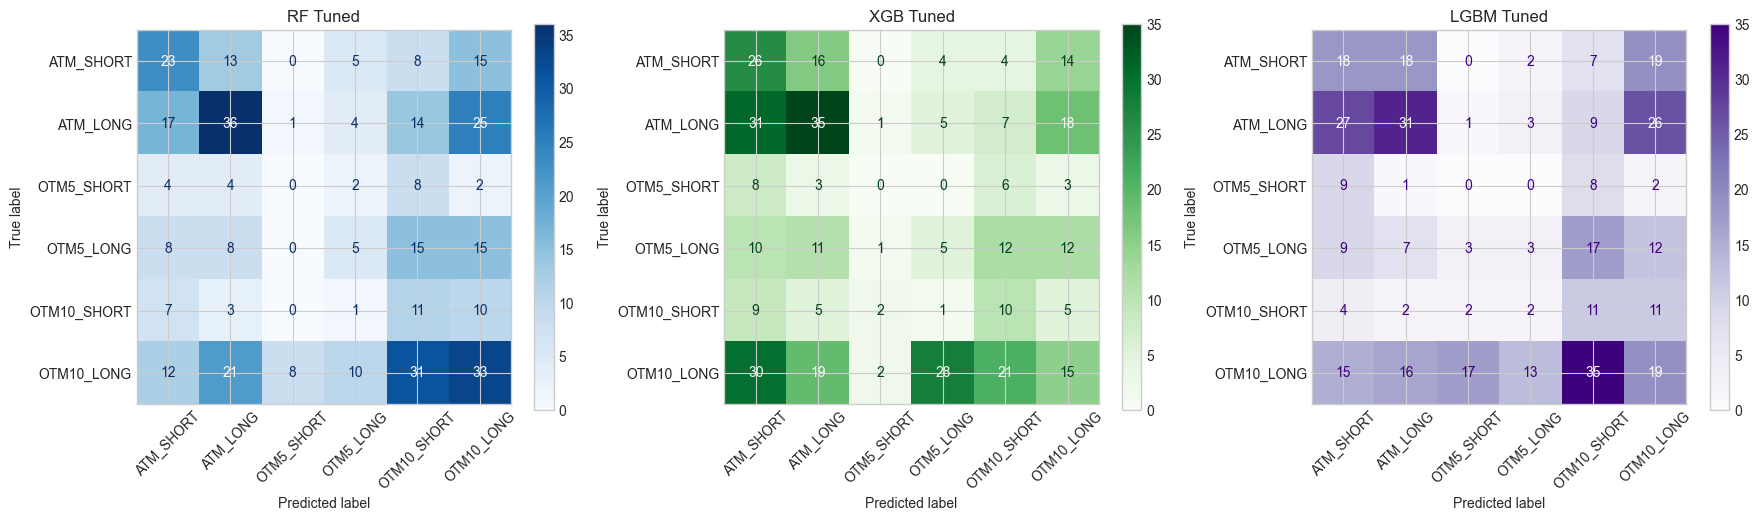

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, cmap) in zip(axes, [
    ('RF Tuned', y_pred_rf, 'Blues'),
    ('XGB Tuned', y_pred_xgb, 'Greens'),
    ('LGBM Tuned', y_pred_lgbm, 'Purples')
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[label_to_bucket_6[i] for i in range(6)])
    disp.plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/improved_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Two-Stage Model

Predict moneyness (3 classes) and maturity (2 classes) separately, using the same time-based split.

In [15]:
# Create separate targets from the same split
data_sorted = data.sort_values('decision_date').reset_index(drop=True)

data_sorted['moneyness'] = data_sorted['best_bucket'].str.split('_').str[0]
data_sorted['maturity'] = data_sorted['bucket_6'].str.split('_').str[1]

moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
maturity_map = {'SHORT': 0, 'LONG': 1}

data_sorted['y_moneyness'] = data_sorted['moneyness'].map(moneyness_map)
data_sorted['y_maturity'] = data_sorted['maturity'].map(maturity_map)

# Same time-based split
train_mask = data_sorted['decision_date'] < split_date
test_mask = data_sorted['decision_date'] >= split_date

y_train_money = data_sorted.loc[train_mask, 'y_moneyness']
y_test_money = data_sorted.loc[test_mask, 'y_moneyness']
y_train_mat = data_sorted.loc[train_mask, 'y_maturity']
y_test_mat = data_sorted.loc[test_mask, 'y_maturity']

print(f"Moneyness train distribution: {np.bincount(y_train_money)}")
print(f"Maturity train distribution: {np.bincount(y_train_mat)}")

Moneyness train distribution: [524 291 197]
Maturity train distribution: [327 685]


In [16]:
# Stage 1: Moneyness (3-class)
print("Tuning Stage 1 -- Moneyness...")

def objective_money(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight': 'balanced',
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train_money, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_money = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_money.optimize(objective_money, n_trials=20, show_progress_bar=True)

money_model = LGBMClassifier(**study_money.best_params, class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1)
money_model.fit(X_train, y_train_money)
money_preds = money_model.predict(X_test)

print(f"Moneyness: Acc={accuracy_score(y_test_money, money_preds):.4f}, F1={f1_score(y_test_money, money_preds, average='macro'):.4f}")
print(classification_report(y_test_money, money_preds, target_names=['ATM', 'OTM5', 'OTM10']))

Tuning Stage 1 — Moneyness...



  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.374307:   0%|          | 0/20 [00:14<?, ?it/s]


Best trial: 0. Best value: 0.374307:   5%|▌         | 1/20 [00:14<04:33, 14.38s/it]


Best trial: 0. Best value: 0.374307:   5%|▌         | 1/20 [00:26<04:33, 14.38s/it]

...


Best trial: 15. Best value: 0.389163:  95%|█████████▌| 19/20 [02:03<00:08,  8.27s/it]


Best trial: 15. Best value: 0.389163:  95%|█████████▌| 19/20 [02:13<00:08,  8.27s/it]


Best trial: 15. Best value: 0.389163: 100%|██████████| 20/20 [02:13<00:00,  8.79s/it]


Best trial: 15. Best value: 0.389163: 100%|██████████| 20/20 [02:13<00:00,  6.67s/it]

Moneyness: Acc=0.3799, F1=0.3012
              precision    recall  f1-score   support

         ATM       0.44      0.68      0.53       161
        OTM5       0.15      0.13      0.14        71
       OTM10       0.37      0.17      0.23       147

    accuracy                           0.38       379
   macro avg       0.32      0.33      0.30       379
weighted avg       0.36      0.38      0.34       379



In [17]:
# Stage 2: Maturity (2-class)
print("Tuning Stage 2 -- Maturity...")

def objective_mat(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight': 'balanced',
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train_mat, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_mat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_mat.optimize(objective_mat, n_trials=20, show_progress_bar=True)

mat_model = LGBMClassifier(**study_mat.best_params, class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1)
mat_model.fit(X_train, y_train_mat)
mat_preds = mat_model.predict(X_test)

print(f"Maturity: Acc={accuracy_score(y_test_mat, mat_preds):.4f}, F1={f1_score(y_test_mat, mat_preds, average='macro'):.4f}")
print(classification_report(y_test_mat, mat_preds, target_names=['SHORT', 'LONG']))

Tuning Stage 2 — Maturity...



  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.450526:   0%|          | 0/20 [00:05<?, ?it/s]


Best trial: 0. Best value: 0.450526:   5%|▌         | 1/20 [00:05<01:50,  5.84s/it]


Best trial: 1. Best value: 0.462951:   5%|▌         | 1/20 [00:09<01:50,  5.84s/it]

...


Best trial: 4. Best value: 0.504806:  95%|█████████▌| 19/20 [00:41<00:02,  2.24s/it]


Best trial: 4. Best value: 0.504806:  95%|█████████▌| 19/20 [00:44<00:02,  2.24s/it]


Best trial: 4. Best value: 0.504806: 100%|██████████| 20/20 [00:44<00:00,  2.39s/it]


Best trial: 4. Best value: 0.504806: 100%|██████████| 20/20 [00:44<00:00,  2.22s/it]

Maturity: Acc=0.5726, F1=0.5240
              precision    recall  f1-score   support

       SHORT       0.34      0.41      0.37       116
        LONG       0.71      0.64      0.68       263

    accuracy                           0.57       379
   macro avg       0.53      0.53      0.52       379
weighted avg       0.60      0.57      0.58       379



In [18]:
# Combine two-stage predictions
y_pred_2stage = money_preds * 2 + mat_preds
y_true_2stage = y_test_money.values * 2 + y_test_mat.values

twostage_acc = accuracy_score(y_true_2stage, y_pred_2stage)
twostage_f1 = f1_score(y_true_2stage, y_pred_2stage, average='macro')
twostage_f1w = f1_score(y_true_2stage, y_pred_2stage, average='weighted')

print(f"Two-Stage Combined (6-class):")
print(f"  Accuracy:    {twostage_acc:.4f}")
print(f"  Macro F1:    {twostage_f1:.4f}")
print(f"  Weighted F1: {twostage_f1w:.4f}")
print(classification_report(y_true_2stage, y_pred_2stage, target_names=[label_to_bucket_6[i] for i in range(6)]))

Two-Stage Combined (6-class):
  Accuracy:    0.2296
  Macro F1:    0.1667
  Weighted F1: 0.2000
              precision    recall  f1-score   support

   ATM_SHORT       0.20      0.31      0.24        64
    ATM_LONG       0.34      0.53      0.41        97
  OTM5_SHORT       0.13      0.15      0.14        20
   OTM5_LONG       0.05      0.04      0.05        51
 OTM10_SHORT       0.05      0.03      0.04        32
  OTM10_LONG       0.21      0.09      0.12       115

    accuracy                           0.23       379
   macro avg       0.16      0.19      0.17       379
weighted avg       0.20      0.23      0.20       379



## 10. Feature Importance (Best Model)

Best model: RF_tuned
            Accuracy  Macro F1  Weighted F1
RF_tuned      0.2850    0.2261       0.2848
XGB_tuned     0.2401    0.1928       0.2283
LGBM_tuned    0.2164    0.1765       0.2169
Two-Stage     0.2296    0.1667       0.2000


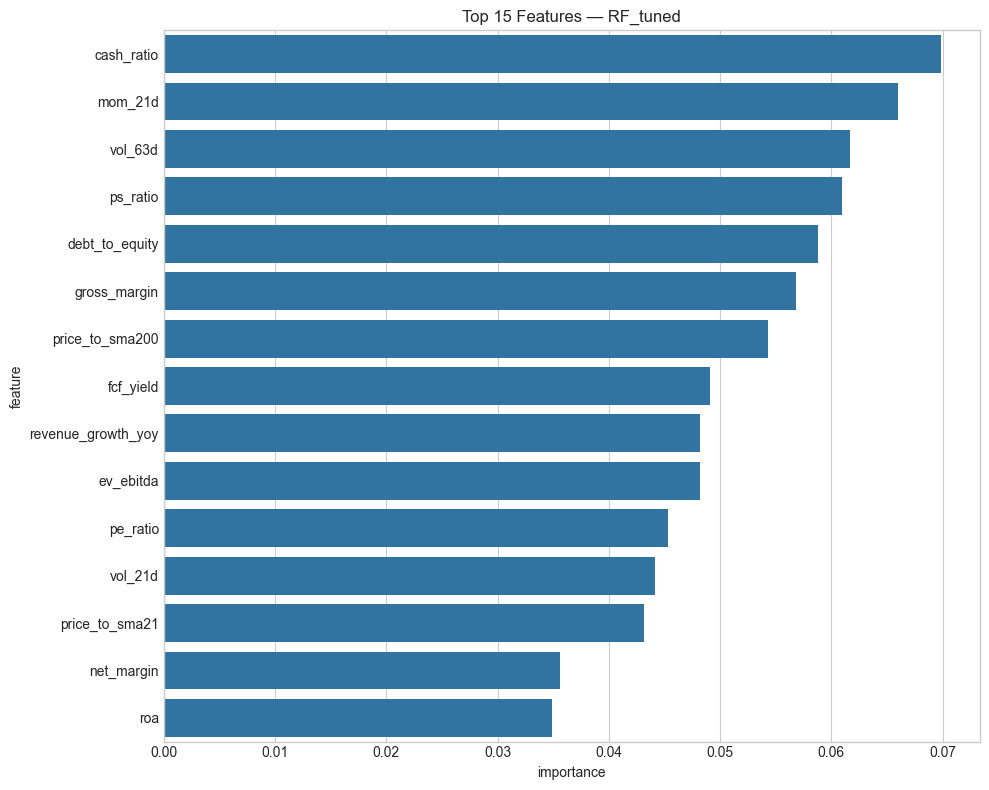

In [19]:
# Collect all results
all_results = results.copy()
all_results['Two-Stage'] = {
    'Accuracy': twostage_acc,
    'Macro F1': twostage_f1,
    'Weighted F1': twostage_f1w,
}
all_results_df = pd.DataFrame(all_results).T.round(4)

best_name = all_results_df['Macro F1'].idxmax()
print(f"Best model: {best_name}")
print(all_results_df)

# Feature importance from best single model
if best_name == 'RF_tuned':
    best_model = rf_tuned
elif best_name == 'XGB_tuned':
    best_model = xgb_tuned
elif best_name == 'LGBM_tuned':
    best_model = lgbm_tuned
else:
    best_model = lgbm_tuned  # use LGBM for two-stage

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=ax)
ax.set_title(f'Top 15 Features -- {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/improved_feature_importance.png', dpi=150)
plt.show()

## 11. Full Comparison

Full Model Comparison:
                           Model  Accuracy  Macro F1
           9-class RF (baseline)    0.3728    0.3581
          9-class XGB (baseline)    0.3871    0.3556
  6-class RF (tuned, time-split)    0.2850    0.2261
 6-class XGB (tuned, time-split)    0.2401    0.1928
6-class LGBM (tuned, time-split)    0.2164    0.1765
  6-class Two-Stage (time-split)    0.2296    0.1667


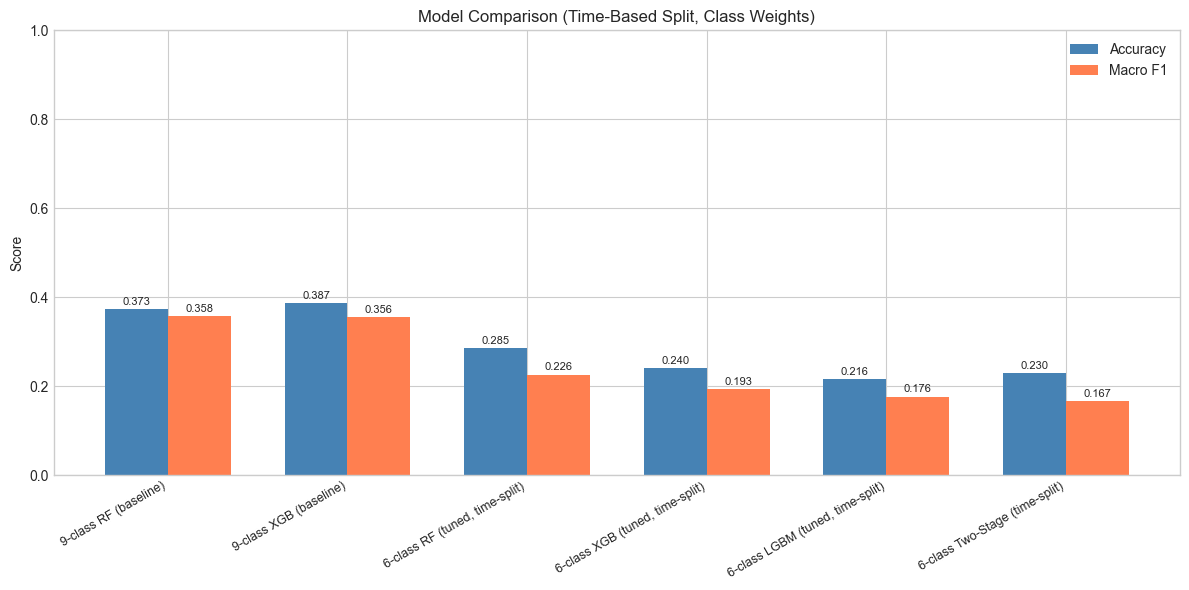

In [20]:
comparison = pd.DataFrame({
    'Model': [
        '9-class RF (baseline)',
        '9-class XGB (baseline)',
        '6-class RF (tuned, time-split)',
        '6-class XGB (tuned, time-split)',
        '6-class LGBM (tuned, time-split)',
        '6-class Two-Stage (time-split)',
    ],
    'Accuracy': [
        0.3728, 0.3871,
        results['RF_tuned']['Accuracy'],
        results['XGB_tuned']['Accuracy'],
        results['LGBM_tuned']['Accuracy'],
        twostage_acc,
    ],
    'Macro F1': [
        0.3581, 0.3556,
        results['RF_tuned']['Macro F1'],
        results['XGB_tuned']['Macro F1'],
        results['LGBM_tuned']['Macro F1'],
        twostage_f1,
    ]
}).round(4)

print("Full Model Comparison:")
print(comparison.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
w = 0.35
b1 = ax.bar(x - w/2, comparison['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, comparison['Macro F1'], w, label='Macro F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison (Time-Based Split, Class Weights)')
ax.legend()
ax.set_ylim(0, 1)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/old_vs_new_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Financial Return Evaluation

Classification F1 doesn't capture whether the model **makes money**. A model could have low F1 but still pick buckets
with returns close to the optimal. Here we compare:
- **Model strategy**: use the predicted bucket's realized return
- **Static strategy**: always pick ATM_LONG (most common class)
- **Oracle**: always pick the best bucket (upper bound)
- **Random**: pick a bucket at random

In [21]:
# Load bucket-level returns to map predictions to realized returns
# Rebuild from label construction data
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
daily_raw = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

options = options[options['symbol'].isin(UNIVERSE)].copy()
daily_raw = daily_raw[daily_raw['symbol'].isin(UNIVERSE)].copy()
calls = options[options['call_put'] == 'CALL'].copy()
calls['expiration'] = pd.to_datetime(calls['expiration'])
calls['trade_date'] = pd.to_datetime(calls['trade_date'])
daily_raw['date'] = pd.to_datetime(daily_raw['date'])
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

# Assign buckets
def assign_moneyness(delta):
    if 0.15 <= delta < 0.30: return 'OTM10'
    elif 0.30 <= delta < 0.45: return 'OTM5'
    elif 0.45 <= delta <= 0.60: return 'ATM'
    return None

def assign_maturity(dte):
    if 7 <= dte <= 37: return 'SHORT'
    elif 38 <= dte <= 120: return 'LONG'
    return None

calls['moneyness'] = calls['delta'].apply(assign_moneyness)
calls['maturity'] = calls['dte'].apply(assign_maturity)
calls_valid = calls.dropna(subset=['moneyness', 'maturity']).copy()
calls_valid['bucket_6'] = calls_valid['moneyness'] + '_' + calls_valid['maturity']

# Merge entry/exit prices
daily_prices = daily_raw[['symbol', 'date', 'adjusted_close']].rename(columns={'adjusted_close': 'price'}).sort_values(['symbol', 'date'])

calls_valid = calls_valid.merge(
    daily_prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'], how='left'
)

# Exit price via per-symbol merge_asof
daily_exit = daily_prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})
results_list = []
for sym in UNIVERSE:
    left = calls_valid[calls_valid['symbol'] == sym].sort_values('expiration')
    right = daily_exit[daily_exit['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']], on='expiration', direction='backward')
    results_list.append(merged)
calls_valid = pd.concat(results_list, ignore_index=True)

# Compute payoff
calls_valid['premium'] = calls_valid['mark'].fillna((calls_valid['bid'] + calls_valid['ask']) / 2)
calls_valid['stock_pnl'] = np.minimum(calls_valid['exit_price'], calls_valid['strike']) - calls_valid['entry_price']
calls_valid['total_pnl'] = calls_valid['premium'] + calls_valid['stock_pnl']
calls_valid['return'] = calls_valid['total_pnl'] / calls_valid['entry_price']

# Filter outliers
calls_valid = calls_valid[(calls_valid['return'] > -0.5) & (calls_valid['return'] < 0.5)].copy()
calls_valid = calls_valid[calls_valid['entry_price'] > 0].copy()
calls_valid = calls_valid[calls_valid['premium'] > 0].copy()

# Aggregate to monthly bucket returns
calls_valid['year_month'] = calls_valid['trade_date'].dt.to_period('M')
bucket_returns = calls_valid.groupby(['symbol', 'year_month', 'bucket_6'])['return'].mean().reset_index()

print(f"Bucket-month return observations: {len(bucket_returns):,}")
print(f"Unique buckets: {sorted(bucket_returns['bucket_6'].unique())}")

Bucket-month return observations: 6,359
Unique buckets: ['ATM_LONG', 'ATM_SHORT', 'OTM10_LONG', 'OTM10_SHORT', 'OTM5_LONG', 'OTM5_SHORT']


In [22]:
# Map 6-class labels back to bucket names
label_to_name = {0:'ATM_SHORT', 1:'ATM_LONG', 2:'OTM5_SHORT', 3:'OTM5_LONG', 4:'OTM10_SHORT', 5:'OTM10_LONG'}

# Get test set with predictions
test_data = data_sorted.loc[test_mask].copy()
test_data['year_month'] = pd.to_datetime(test_data['decision_date']).dt.to_period('M')

# Add all model predictions
test_data['pred_rf'] = y_pred_rf
test_data['pred_xgb'] = y_pred_xgb
test_data['pred_lgbm'] = y_pred_lgbm
test_data['pred_2stage'] = y_pred_2stage
test_data['true_label'] = test_data['label_6'].values

def get_strategy_return(test_df, pred_col, bucket_returns_df):
    """For each test row, look up the realized return of the predicted bucket."""
    returns = []
    for _, row in test_df.iterrows():
        pred_bucket = label_to_name[row[pred_col]]
        match = bucket_returns_df[
            (bucket_returns_df['symbol'] == row['symbol']) &
            (bucket_returns_df['year_month'] == row['year_month']) &
            (bucket_returns_df['bucket_6'] == pred_bucket)
        ]
        if len(match) > 0:
            returns.append(match['return'].values[0])
        else:
            returns.append(np.nan)
    return np.array(returns)

# Oracle: always pick the best bucket (from labels)
oracle_returns = get_strategy_return(test_data, 'true_label', bucket_returns)

# Static: always pick ATM_LONG (label=1, most common)
test_data['static_atm_long'] = 1
static_returns = get_strategy_return(test_data, 'static_atm_long', bucket_returns)

# Model strategies
rf_returns = get_strategy_return(test_data, 'pred_rf', bucket_returns)
xgb_returns = get_strategy_return(test_data, 'pred_xgb', bucket_returns)
lgbm_returns = get_strategy_return(test_data, 'pred_lgbm', bucket_returns)
twostage_returns = get_strategy_return(test_data, 'pred_2stage', bucket_returns)

# Random baseline (average across all available buckets per month)
random_returns = []
for _, row in test_data.iterrows():
    match = bucket_returns_df[
        (bucket_returns_df['symbol'] == row['symbol']) &
        (bucket_returns_df['year_month'] == row['year_month'])
    ] if False else bucket_returns[
        (bucket_returns['symbol'] == row['symbol']) &
        (bucket_returns['year_month'] == row['year_month'])
    ]
    if len(match) > 0:
        random_returns.append(match['return'].mean())
    else:
        random_returns.append(np.nan)
random_returns = np.array(random_returns)

print("Strategy return lookup complete.")
print(f"Test rows with return data: {np.sum(~np.isnan(oracle_returns))} / {len(test_data)}")

Strategy return lookup complete.
Test rows with return data: 379 / 379


In [23]:
# Compute summary statistics
def summarize_returns(returns, name):
    valid = returns[~np.isnan(returns)]
    if len(valid) == 0:
        return {'Strategy': name, 'Mean Return': np.nan, 'Std': np.nan, 'Sharpe': np.nan, 'Total': np.nan}
    mean_r = np.mean(valid)
    std_r = np.std(valid)
    sharpe = mean_r / std_r * np.sqrt(12) if std_r > 0 else 0  # annualized monthly Sharpe
    cumulative = np.prod(1 + valid) - 1
    return {
        'Strategy': name,
        'Mean Monthly Return': f'{mean_r:.4f}',
        'Std': f'{std_r:.4f}',
        'Annualized Sharpe': f'{sharpe:.2f}',
        'Cumulative Return': f'{cumulative:.2%}',
        'N': len(valid)
    }

fin_results = pd.DataFrame([
    summarize_returns(oracle_returns, 'Oracle (best possible)'),
    summarize_returns(rf_returns, 'RF Tuned'),
    summarize_returns(xgb_returns, 'XGB Tuned'),
    summarize_returns(lgbm_returns, 'LGBM Tuned'),
    summarize_returns(twostage_returns, 'Two-Stage'),
    summarize_returns(static_returns, 'Static (always ATM_LONG)'),
    summarize_returns(random_returns, 'Random (avg all buckets)'),
])

print("Financial Performance Comparison (Test Period: 2022-07 to 2025-12):")
print(fin_results.to_string(index=False))

Financial Performance Comparison (Test Period: 2022-07 to 2025-12):
                Strategy Mean Monthly Return    Std Annualized Sharpe       Cumulative Return   N
  Oracle (best possible)              0.1124 0.1427              2.73 1914273619776762880.00% 379
                RF Tuned              0.0638 0.1235              1.79         31991533581.54% 353
               XGB Tuned              0.0634 0.1268              1.73         26165626049.56% 353
              LGBM Tuned              0.0605 0.1231              1.70         14292715259.64% 358
               Two-Stage              0.0564 0.1203              1.62          1493770105.77% 338
Static (always ATM_LONG)              0.0535 0.1099              1.69           234594877.09% 312
Random (avg all buckets)              0.0642 0.1169              1.90        203282526310.07% 379


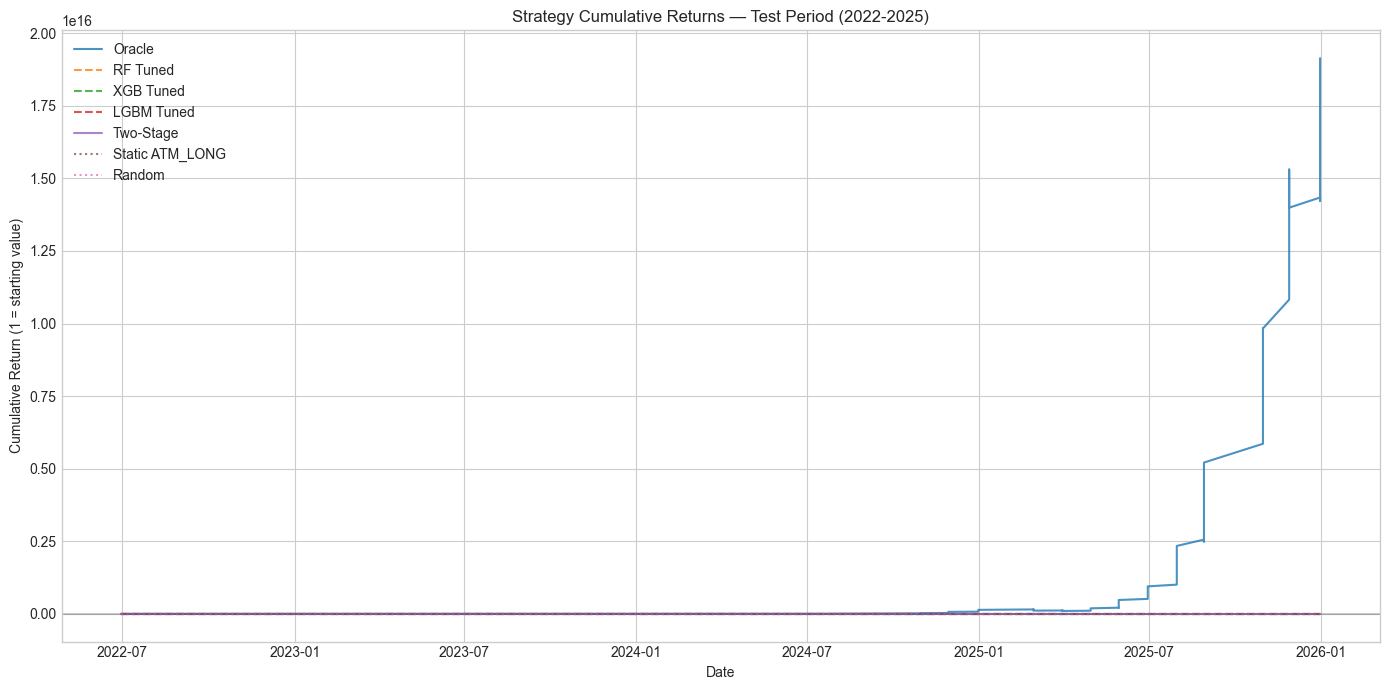

In [24]:
# Cumulative return plot
fig, ax = plt.subplots(figsize=(14, 7))

# Get dates for x-axis
test_dates = pd.to_datetime(test_data['decision_date'].values)

for returns, name, style in [
    (oracle_returns, 'Oracle', '-'),
    (rf_returns, 'RF Tuned', '--'),
    (xgb_returns, 'XGB Tuned', '--'),
    (lgbm_returns, 'LGBM Tuned', '--'),
    (twostage_returns, 'Two-Stage', '-'),
    (static_returns, 'Static ATM_LONG', ':'),
    (random_returns, 'Random', ':'),
]:
    valid_mask = ~np.isnan(returns)
    cum = np.cumprod(1 + np.nan_to_num(returns, nan=0)) 
    ax.plot(test_dates, cum, label=name, linestyle=style, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (1 = starting value)')
ax.set_title('Strategy Cumulative Returns -- Test Period (2022-2025)')
ax.legend(loc='upper left')
ax.axhline(y=1, color='black', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.savefig('../reports/figures/financial_returns_comparison.png', dpi=150)
plt.show()

In [25]:
# Top-2 accuracy: is the true best bucket in the model's top 2 predictions?
# Use RF (best F1 model) predict_proba
rf_proba = rf_tuned.predict_proba(X_test)
top2_preds = np.argsort(rf_proba, axis=1)[:, -2:]  # top 2 class indices
top2_correct = np.array([y_test.iloc[i] in top2_preds[i] for i in range(len(y_test))])

print(f"Top-1 Accuracy (RF): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Top-2 Accuracy (RF): {top2_correct.mean():.4f}")
print(f"\nThis means {top2_correct.mean()*100:.1f}% of the time, the correct bucket is in the model's top 2 picks.")

Top-1 Accuracy (RF): 0.2850
Top-2 Accuracy (RF): 0.5119

This means 51.2% of the time, the correct bucket is in the model's top 2 picks.


## 13. Save Models

In [ ]:
# Save all tuned models
joblib.dump(rf_tuned, MODELS / 'rf_tuned_6class.joblib')
joblib.dump(xgb_tuned, MODELS / 'xgb_tuned_6class.joblib')
joblib.dump(lgbm_tuned, MODELS / 'lgbm_tuned_6class.joblib')
joblib.dump(money_model, MODELS / 'twostage_moneyness.joblib')
joblib.dump(mat_model, MODELS / 'twostage_maturity.joblib')

# Save metadata
metadata = {
    'feature_cols': feature_cols,
    'label_map_6': label_map_6,
    'moneyness_map': {'ATM': 0, 'OTM5': 1, 'OTM10': 2},
    'maturity_map': {'SHORT': 0, 'LONG': 1},
    'split_date': str(pd.Timestamp(split_date).date()),
    'best_model': best_name,
    'best_rf_params': study_rf.best_params,
    'best_xgb_params': study_xgb.best_params,
    'best_lgbm_params': study_lgbm.best_params,
    'approach': 'time-based split, class weights',
}
with open(MODELS / 'improved_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

comparison.to_csv(PROCESSED / 'improved_results.csv', index=False)

print("All models and results saved.")
print(f"\nBest model: {best_name} (Macro F1: {all_results_df.loc[best_name, 'Macro F1']:.4f})")

All models and results saved.

Best model: RF_tuned (Macro F1: 0.2261)
